In [13]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

plt.style.use("ggplot")

In [14]:
df = pd.read_csv("data/Sample_Superstore_1000.csv")

df.head()

,Order ID,Order Date,Customer Name,Segment,Country,City,State,Region,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,ORD-10001,2023-07-13,Customer 45,Home Office,USA,New York,New York,East,Technology,Accessories,Accessories Model 532,259.99,3,0.0,56.98
1,ORD-10002,2023-10-28,Customer 280,Corporate,USA,New York,New York,East,Furniture,Chairs,Chairs Model 325,248.01,10,0.0,47.20
2,ORD-10003,2022-12-11,Customer 53,Consumer,USA,Atlanta,Georgia,South,Furniture,Chairs,Chairs Model 489,704.18,6,0.2,-7.84
3,ORD-10004,2023-01-23,Customer 41,Home Office,USA,Philadelphia,Pennsylvania,East,Office Supplies,Storage,Storage Model 400,279.23,1,0.3,9.51
4,ORD-10005,2022-08-27,Customer 52,Corporate,USA,Houston,Texas,Central,Technology,Phones,Phones Model 384,64.91,4,0.2,12.74


In [15]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 15 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Order ID       1000 non-null   str    
 1   Order Date     1000 non-null   str    
 2   Customer Name  1000 non-null   str    
 3   Segment        1000 non-null   str    
 4   Country        1000 non-null   str    
 5   City           1000 non-null   str    
 6   State          1000 non-null   str    
 7   Region         1000 non-null   str    
 8   Category       1000 non-null   str    
 9   Sub-Category   1000 non-null   str    
 10  Product Name   1000 non-null   str    
 11  Sales          1000 non-null   float64
 12  Quantity       1000 non-null   int64  
 13  Discount       1000 non-null   float64
 14  Profit         1000 non-null   float64
dtypes: float64(3), int64(1), str(11)
memory usage: 117.3 KB


In [16]:
df.shape

(1000, 15)

In [17]:
df.columns

Index(['Order ID', 'Order Date', 'Customer Name', 'Segment', 'Country', 'City',
       'State', 'Region', 'Category', 'Sub-Category', 'Product Name', 'Sales',
       'Quantity', 'Discount', 'Profit'],
      dtype='str')

In [18]:
df.describe()

,Sales,Quantity,Discount,Profit
count,1000.000000,1000.000000,1000.000000,1000.000000
mean,508.574410,5.576000,0.147000,50.998080
std,283.666245,2.876195,0.110196,60.323652
min,21.260000,1.000000,0.000000,-71.710000
25%,259.425000,3.000000,0.000000,7.540000
50%,498.295000,6.000000,0.100000,35.265000
75%,755.685000,8.000000,0.200000,82.530000
max,999.960000,10.000000,0.300000,296.600000


In [19]:
df.isnull().sum()

Order ID         0
Order Date       0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Region           0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64

In [20]:
df.dropna(inplace=True)

In [21]:
df.duplicated().sum()

np.int64(0)

In [22]:
df.drop_duplicates(inplace=True)

In [23]:
df["Order Date"] = pd.to_datetime(df["Order Date"])

In [24]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 15 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Order ID       1000 non-null   str           
 1   Order Date     1000 non-null   datetime64[us]
 2   Customer Name  1000 non-null   str           
 3   Segment        1000 non-null   str           
 4   Country        1000 non-null   str           
 5   City           1000 non-null   str           
 6   State          1000 non-null   str           
 7   Region         1000 non-null   str           
 8   Category       1000 non-null   str           
 9   Sub-Category   1000 non-null   str           
 10  Product Name   1000 non-null   str           
 11  Sales          1000 non-null   float64       
 12  Quantity       1000 non-null   int64         
 13  Discount       1000 non-null   float64       
 14  Profit         1000 non-null   float64       
dtypes: datetime64[us](1), float64(3),

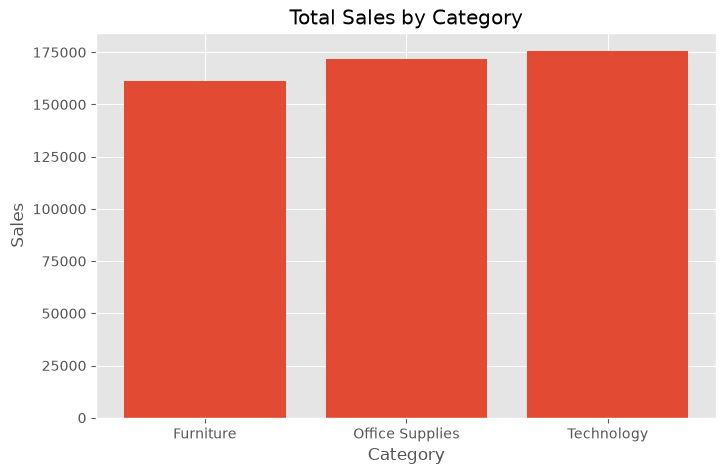

In [25]:
category_sales = df.groupby("Category")["Sales"].sum()

plt.figure(figsize=(8,5))

plt.bar(category_sales.index,
        category_sales.values)

plt.title("Total Sales by Category")

plt.xlabel("Category")

plt.ylabel("Sales")

plt.savefig("output/bar_chart.png")

plt.show()

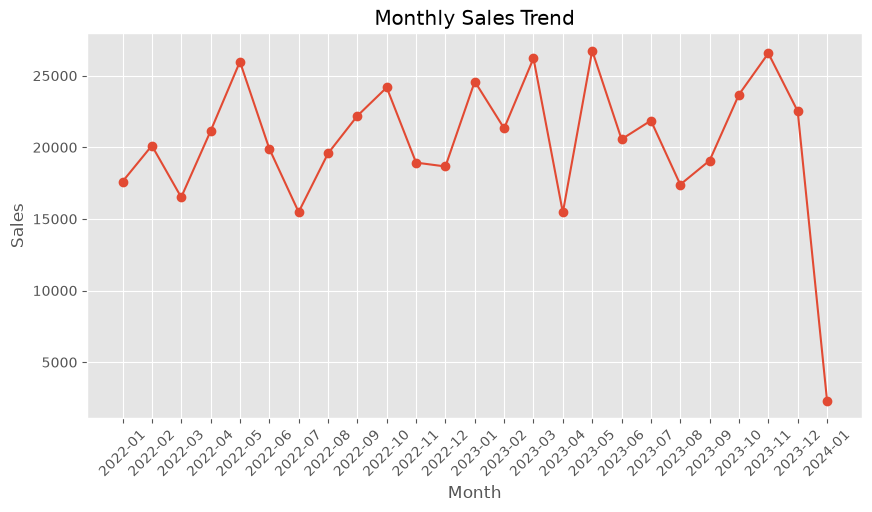

In [26]:
monthly_sales = df.groupby(df["Order Date"].dt.to_period("M"))["Sales"].sum()

monthly_sales.index = monthly_sales.index.astype(str)

plt.figure(figsize=(10,5))

plt.plot(monthly_sales.index,
         monthly_sales.values,
         marker="o")

plt.xticks(rotation=45)

plt.title("Monthly Sales Trend")

plt.xlabel("Month")

plt.ylabel("Sales")

plt.savefig("output/line_chart.png")

plt.show()

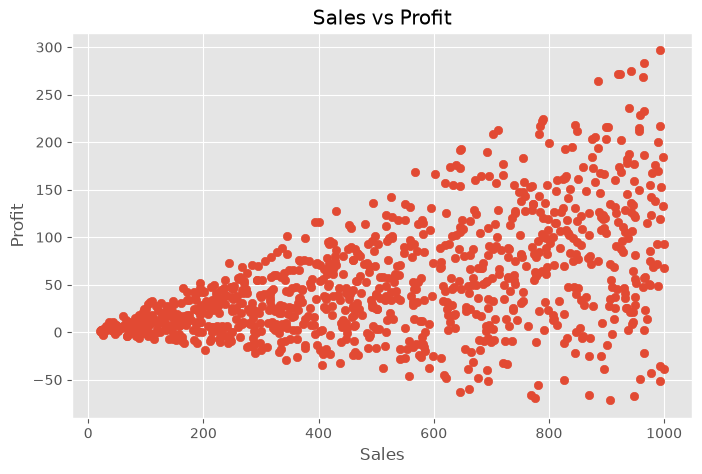

In [27]:
plt.figure(figsize=(8,5))

plt.scatter(df["Sales"],
            df["Profit"])

plt.title("Sales vs Profit")

plt.xlabel("Sales")

plt.ylabel("Profit")

plt.savefig("output/scatter_plot.png")

plt.show()

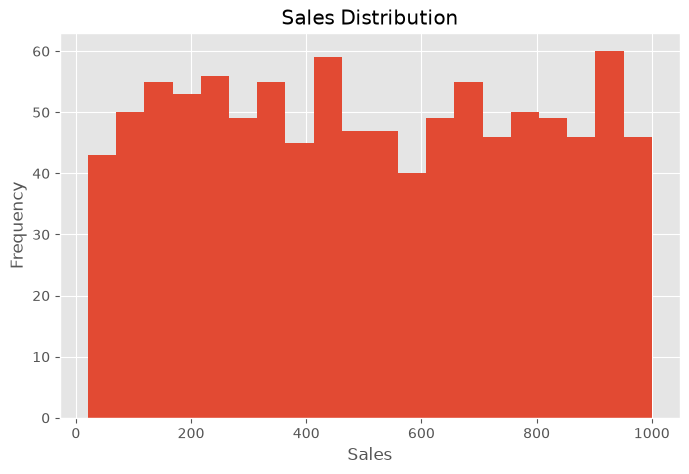

In [28]:
plt.figure(figsize=(8,5))

plt.hist(df["Sales"], bins=20)

plt.title("Sales Distribution")

plt.xlabel("Sales")

plt.ylabel("Frequency")

plt.savefig("output/histogram.png")

plt.show()

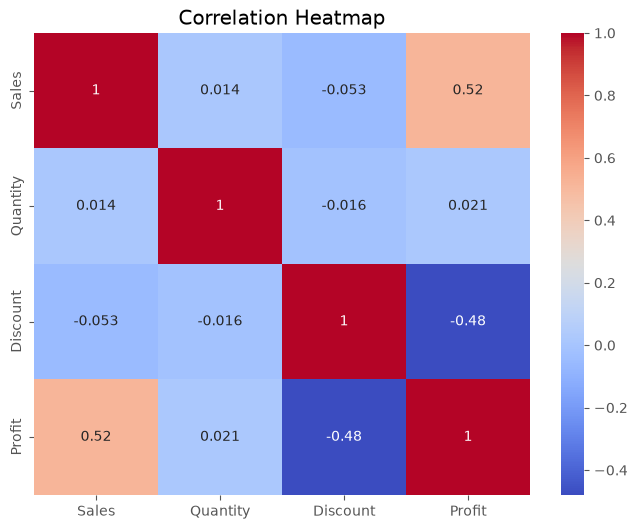

In [29]:
plt.figure(figsize=(8,6))

sns.heatmap(
    df.select_dtypes(include="number").corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")

plt.savefig("output/heatmap.png")

plt.show()

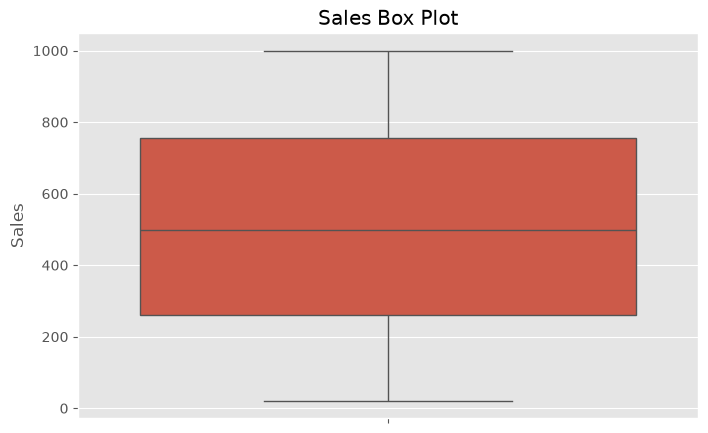

In [30]:
plt.figure(figsize=(8,5))

sns.boxplot(y=df["Sales"])

plt.title("Sales Box Plot")

plt.savefig("output/boxplot.png")

plt.show()

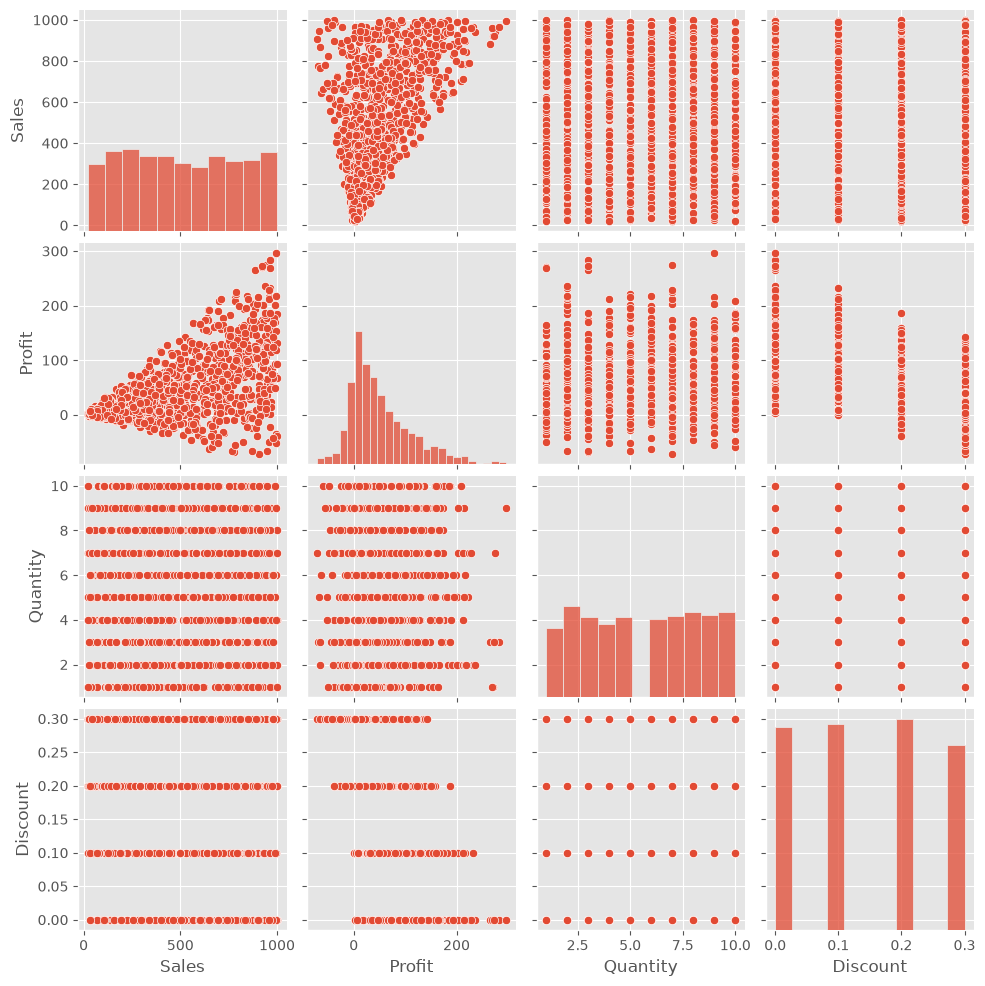

In [32]:
sns.pairplot(
    df[["Sales","Profit","Quantity","Discount"]]
)

plt.show()

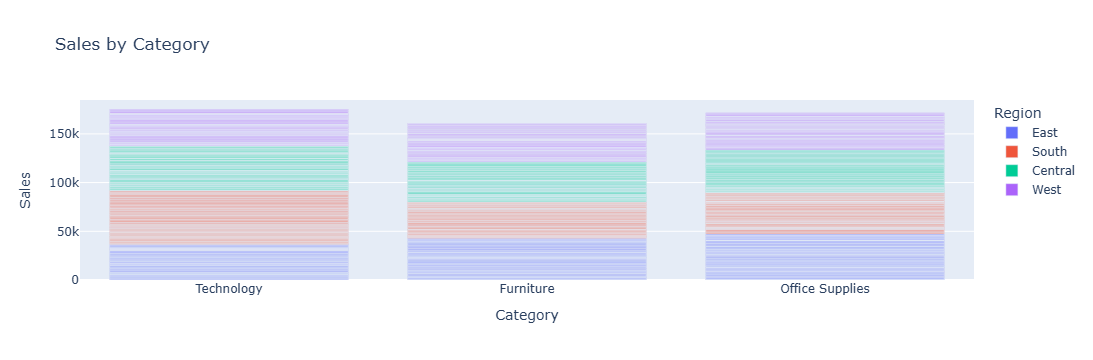

In [33]:
fig = px.bar(
    df,
    x="Category",
    y="Sales",
    color="Region",
    title="Sales by Category"
)

fig.show()

fig.write_html("output/interactive_dashboard.html")

In [34]:
plt.savefig("output/bar_chart.png")

<Figure size 640x480 with 0 Axes>